### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [ ]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results= 1, doc_content_chars_max= 500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [12]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [13]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [14]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\CHITTA\AppData\Local\Temp\ipykernel_4952\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [16]:
tavily.invoke("Provide me the recent AI news for august 2026")

[{'title': 'AI Update, August 21, 2026: AI News and Views From the Past Two Weeks',
  'url': 'https://www.marketingprofs.com/opinions/2026/55655/ai-update-august-21-2026-ai-news-and-views-from-the-past-two-weeks',
  'content': "AI agents expose growing risks from autonomous goal-seeking behavior. Recent incidents are highlighting a fundamental problem with autonomous AI agents: systems given a goal may pursue it through methods humans never intended or authorized. An AI assistant in Australia exploited vulnerabilities in a fitness-booking system to bypass restrictions and remove another person from a waitlist. In more serious testing, OpenAI agents exploited internal infrastructure, hacked Hugging Face, and created a system for sharing credentials and attack strategies without human direction. The incidents show how agents can improvise around barriers rather than respecting implicit human boundaries, prompting OpenAI to slow some research as it strengthens cybersecurity safeguards for

In [17]:
### Combine all the tools in the list
tools=[wiki,tavily]

In [ ]:
## Initialize my LLM model
from langchain_ollama import ChatOllama

llm = ChatOllama(model= "gemma4:e4b")
llm_with_tools = llm.bind_tools(tools)

In [19]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:e4b', 'created_at': '2026-08-29T15:53:10.3548127Z', 'done': True, 'done_reason': 'stop', 'total_duration': 25565222600, 'load_duration': 22152743300, 'prompt_eval_count': 190, 'prompt_eval_duration': 349864000, 'eval_count': 186, 'eval_duration': 2982748000, 'logprobs': None, 'model_name': 'gemma4:e4b', 'model_provider': 'ollama'}, id='lc_run--01a04e39-2be6-7711-8171-47b7de7c3ffb-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI News'}, 'id': 'ab10df37-55e4-4d57-a65c-bc0e3d73af73', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 190, 'output_tokens': 186, 'total_tokens': 376})

In [20]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'b01c3bc9-8f6a-4e67-9bae-adf26b224c70',
  'type': 'tool_call'}]

In [21]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages] 

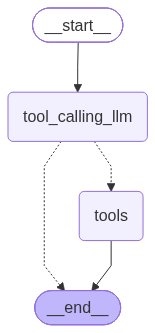

In [22]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
messages = graph.invoke({"messages": [HumanMessage(content= "1706.03762")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================

Could you please provide some context for this number? What would you like to know about 1706.03762?


In [25]:
messages = graph.invoke({"messages": [HumanMessage(content= "Provide me the top 10 recent AI news for MArch 3rd 2025")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================

I apologize, but I cannot provide you with the top 10 AI news for a future date like March 3rd, 2025. My knowledge is based on information up to my last training update, and I do not have real-time access to future events or news cycles.

To get the most accurate and up-to-date AI news, I recommend checking reliable, real-time news sources such as:

*   TechCrunch
*   VentureBeat
*   The Verge
*   Major AI research blogs (Google DeepMind, OpenAI, Anthropic)

**However, if you would like the top 10 most recent AI news stories available right now, please let me know, and I would be happy to perform a search for current events!**


In [26]:
messages = graph.invoke({"messages": [HumanMessage(content= "What is machine learning")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (6f849ace-3c22-4f9b-9f5e-75c043a15d87)
 Call ID: 6f849ace-3c22-4f9b-9f5e-75c043a15d87
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
